# 05 — AI Resume Matching (RAG): Data Understanding (EDA)

La pregunta de negocio detrás de este proyecto es fácil de enunciar y no tanto de resolver: ¿cómo automatizamos el matching semántico (no solo por keyword) entre vacantes y CVs, y encima dejamos el ranking explicable?

Antes de escribir una sola línea de análisis tuve que replantear el alcance. La idea original hablaba de "~2.400 CVs categorizados por rol" — currículums sueltos, sin vacantes asociadas. Lo que bajé de Kaggle (`resume_data.csv`) resultó ser otra cosa, y mejor: pares candidato–vacante ya armados, con campos de ambos lados (CV y descripción del puesto) y un `matched_score` precalculado. Este notebook arranca ahí, entendiendo la estructura real antes de asumir nada del plan original.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

DATA_PATH = '../data/resume_data.csv'

## 1. Carga de datos

Primer tropiezo, chico pero raro: la columna `job_position_name` trae un carácter BOM (`﻿`) pegado al nombre. No está al inicio del archivo — si lo estuviera, `encoding='utf-8-sig'` lo resolvería solo — sino incrustado justo en ese punto del CSV. Tocó limpiarlo a mano de los nombres de columna después de leer.

In [2]:
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
df.columns = [c.replace('﻿', '') for c in df.columns]
print(df.shape)
df.columns.tolist()

(9544, 35)


['address',
 'career_objective',
 'skills',
 'educational_institution_name',
 'degree_names',
 'passing_years',
 'educational_results',
 'result_types',
 'major_field_of_studies',
 'professional_company_names',
 'company_urls',
 'start_dates',
 'end_dates',
 'related_skils_in_job',
 'positions',
 'locations',
 'responsibilities',
 'extra_curricular_activity_types',
 'extra_curricular_organization_names',
 'extra_curricular_organization_links',
 'role_positions',
 'languages',
 'proficiency_levels',
 'certification_providers',
 'certification_skills',
 'online_links',
 'issue_dates',
 'expiry_dates',
 'job_position_name',
 'educationaL_requirements',
 'experiencere_requirement',
 'age_requirement',
 'responsibilities.1',
 'skills_required',
 'matched_score']

## 2. Bug de nombres de columna: dos columnas se llaman `responsibilities`

El CSV trae, literalmente, dos columnas llamadas `responsibilities`: una del lado del CV (lo que hizo el candidato en trabajos anteriores) y otra del lado de la vacante (lo que pide el puesto). Pandas resuelve el choque solo, renombrando la segunda a `responsibilities.1`, sin avisar de nada. Fácil de pasar por alto si uno no revisa la lista de columnas con cuidado — así que las renombro explícitamente antes de seguir, en vez de dejar el nombre genérico que pandas asignó por accidente.

In [3]:
df = df.rename(columns={
    'responsibilities': 'candidate_past_responsibilities',
    'responsibilities.1': 'job_responsibilities',
})
print('Confirmado, columna ambigua resuelta.')

Confirmado, columna ambigua resuelta.


## 3. La estructura real: esto no son 9.544 CVs, son pares candidato–vacante

In [4]:
resume_fields = ['career_objective', 'skills', 'educational_institution_name', 'degree_names', 'professional_company_names']
job_fields = ['job_position_name', 'educationaL_requirements', 'experiencere_requirement', 'age_requirement', 'skills_required', 'job_responsibilities']

print('Campos del lado del CV (ejemplos):', resume_fields)
print('Campos del lado de la vacante (ejemplos):', job_fields)
print()
print('Vacantes únicas:', df['job_position_name'].nunique())
print(df['job_position_name'].value_counts().head(5))

Campos del lado del CV (ejemplos): ['career_objective', 'skills', 'educational_institution_name', 'degree_names', 'professional_company_names']
Campos del lado de la vacante (ejemplos): ['job_position_name', 'educationaL_requirements', 'experiencere_requirement', 'age_requirement', 'skills_required', 'job_responsibilities']

Vacantes únicas: 28
job_position_name
Project Coordinator (Civil)    342
HR Officer                     342
Civil Engineer                 342
Site Engineer                  342
Senior Software Engineer       341
Name: count, dtype: int64


In [5]:
resume_fingerprint = df['career_objective'].fillna('') + '|' + df['skills'].fillna('')
n_unique_resumes = resume_fingerprint.nunique()
print(f'Filas totales: {len(df)}')
print(f'CVs únicos (por huella de career_objective + skills): {n_unique_resumes}')
print()
print('¿Cuántas vacantes distintas ve cada CV único?')
print(resume_fingerprint.value_counts().value_counts().sort_index())

Filas totales: 9544
CVs únicos (por huella de career_objective + skills): 344

¿Cuántas vacantes distintas ve cada CV único?
count
4       1
6       1
10      1
12      1
20      1
28    339
Name: count, dtype: int64


Este es el hallazgo que más importa de todo el EDA. El dataset tiene 344 CVs únicos, cada uno emparejado contra (casi) las 28 vacantes — un cruce casi completo de 344 × 28 ≈ 9.632 combinaciones posibles, de las cuales existen 9.544 (algunos candidatos se quedaron sin ver las 28). Esto no es un detalle menor: cambia el diseño de `02_data_preparation.ipynb` de raíz. El índice FAISS de candidatos tiene que construirse sobre esos 344 CVs únicos, no sobre las 9.544 filas del CSV — indexar las filas tal cual metería al mismo candidato 28 veces en el índice vectorial.

## 4. Nulos

La mayoría no son errores de captura, son estructurales: no todo candidato completa certificaciones, idiomas o actividades extracurriculares al armar su CV.

In [6]:
nulls = df.isnull().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(df) * 100).round(1)
pd.DataFrame({'nulos': nulls, '% del total': nulls_pct}).head(15)

,nulos,% del total
languages,8844,92.7
proficiency_levels,8844,92.7
address,8760,91.8
issue_dates,7536,79.0
certification_skills,7536,79.0
certification_providers,7536,79.0
expiry_dates,7536,79.0
online_links,7536,79.0
extra_curricular_activity_types,6118,64.1
extra_curricular_organization_links,6118,64.1


`languages`/`proficiency_levels` (92.7%), `address` (91.8%), datos de certificación (79%) — en los tres casos lo más probable es que el candidato simplemente no llenó esa sección, no que se perdió información al capturar los datos. Para Data Preparation la decisión es tratarlos como texto vacío al construir el perfil combinado del candidato, en vez de eliminar filas y perder señal de otras columnas que sí están completas.

## 5. ¿Hay duplicados exactos?

In [7]:
print('Filas duplicadas exactas:', df.duplicated().sum())

Filas duplicadas exactas: 0


## 6. La variable `matched_score`

count    9544.000000
mean        0.660831
std         0.167040
min         0.000000
25%         0.583333
50%         0.683333
75%         0.793333
max         0.970000
Name: matched_score, dtype: float64


C:\Users\migue\AppData\Local\Temp\ipykernel_22316\1193138669.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


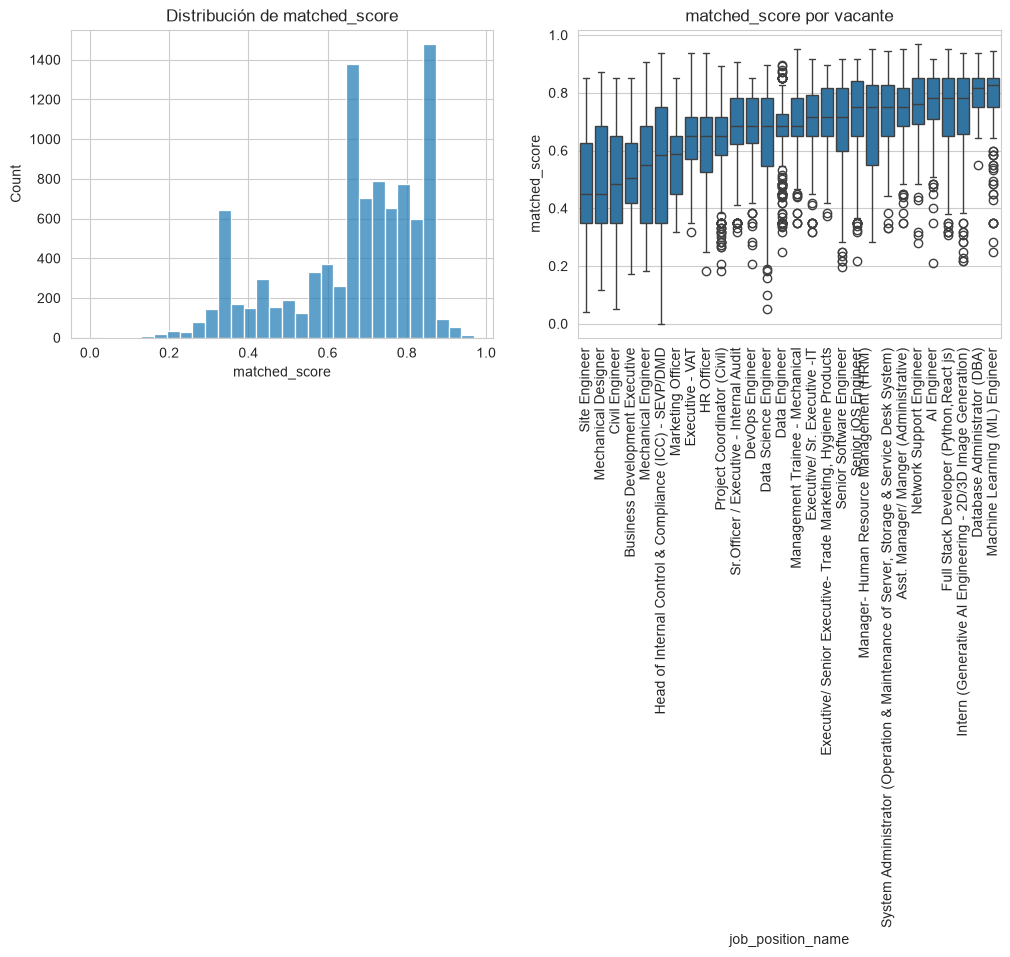

In [8]:
print(df['matched_score'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['matched_score'], bins=30, ax=axes[0], color='#2980b9')
axes[0].set_title('Distribución de matched_score')

order = df.groupby('job_position_name')['matched_score'].median().sort_values().index
sns.boxplot(data=df, x='job_position_name', y='matched_score', order=order, ax=axes[1])
axes[1].tick_params(axis='x', rotation=90)
axes[1].set_title('matched_score por vacante')
plt.tight_layout()
plt.show()

## 7. ¿`matched_score` es solo overlap de palabras clave?

Antes de apoyarme en `matched_score` como referencia para validar el recomendador semántico, necesitaba descartar algo: que fuera, en el fondo, un simple conteo de palabras compartidas entre `skills` y `skills_required`. Si así fuera, no aportaría ninguna señal por encima de un matching literal por keyword — justo lo que este proyecto quiere superar.

In [9]:
import re

def tokenize(s):
    if pd.isnull(s):
        return set()
    return set(re.findall(r'[a-zA-Z]+', str(s).lower()))

skills_tok = df['skills'].apply(tokenize)
req_tok = df['skills_required'].apply(tokenize)
overlap = [len(a & b) for a, b in zip(skills_tok, req_tok)]
union = [max(len(a | b), 1) for a, b in zip(skills_tok, req_tok)]
jaccard = pd.Series(overlap) / pd.Series(union)

print('Correlación (overlap de keywords de skills, matched_score):', pd.Series(overlap).corr(df['matched_score']))
print('Correlación (Jaccard de skills, matched_score):', jaccard.corr(df['matched_score']))

Correlación (overlap de keywords de skills, matched_score): 0.13975167066292501
Correlación (Jaccard de skills, matched_score): 0.1251581546837962


La correlación da débil, entre 0.13 y 0.14 según la métrica. `matched_score` no es una función trivial del overlap de palabras entre `skills` y `skills_required` — algo bueno, en realidad: es consistente con que quien armó el dataset haya usado un método más sofisticado (probablemente semántico) para calcularlo, en vez de contar keywords compartidas. Eso lo vuelve razonable como referencia de validación para el recomendador en `03_modeling.ipynb`. Dicho esto, sigue siendo un score de un tercero, no una etiqueta verificada por humanos — lo documento como limitación, no como ground truth absoluto.

## 8. Longitud de texto en los campos principales

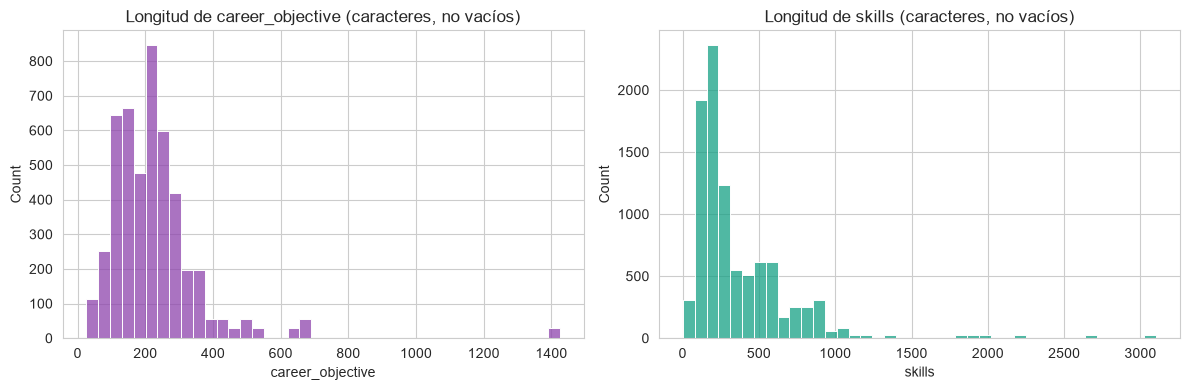

In [10]:
career_len = df['career_objective'].fillna('').str.len()
skills_len = df['skills'].fillna('').str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(career_len[career_len > 0], bins=40, ax=axes[0], color='#8e44ad')
axes[0].set_title('Longitud de career_objective (caracteres, no vacíos)')
sns.histplot(skills_len[skills_len > 0], bins=40, ax=axes[1], color='#16a085')
axes[1].set_title('Longitud de skills (caracteres, no vacíos)')
plt.tight_layout()
plt.show()

## Balance de esta primera pasada

Con esto ya tengo un panorama bastante claro de lo que hay en el dataset y de lo que hace falta ajustar antes de modelar:

- El dataset real es distinto al que tenía planeado usar: no son CVs sueltos, son pares candidato–vacante con `matched_score` ya calculado — mejor punto de partida, pero obliga a replantear el diseño original.
- 344 CVs únicos, no 9.544. El índice FAISS de `03_modeling.ipynb` tiene que construirse sobre esos 344, no sobre las filas del CSV.
- El bug de las dos columnas `responsibilities` quedó resuelto — se renombraron para eliminar la ambigüedad que pandas dejaba pasar en silencio.
- Los nulos son mayormente estructurales (certificaciones, idiomas, dirección); se completan como texto vacío, no se eliminan filas.
- `matched_score` no es un score de keywords trivial (correlación ~0.13 con el overlap de skills) — sirve como referencia de validación para el recomendador semántico, pero queda documentado como score de un tercero, no como ground truth verificado por humanos.
- No hay duplicados exactos de fila.

El siguiente paso es `02_data_preparation.ipynb`: deduplicar a los 344 CVs únicos, armar el perfil de texto combinado por candidato y por vacante, y dejar todo listo para el pipeline de embeddings + FAISS.